# 01 · 로지스틱 회귀 — 뉴런 하나를 학습시킨다

**코세라 C1W2 (Neural Networks Basics).**

[00번](00_perceptron.ipynb)에서 두 가지가 막혔다.

1. 계단함수는 미분이 거의 어디서나 0이라 경사하강이 방향을 알 수 없다.
2. 출력이 0/1뿐이라 "얼마나 틀렸는지"를 모른다.

둘 다 계단함수를 **시그모이드**로 바꾸면 풀린다. 그렇게 바꾼 뉴런 하나가
로지스틱 회귀이고, 이것이 신경망의 최소 단위다.

이 노트북에서 하는 것

- 시그모이드와 그 도함수를 유도한다
- **왜 제곱오차가 아니라 로그 손실인가**를 두 가지 근거로 확인한다
- 계산 그래프를 따라 역전파를 유도한다 — 결과는 놀랍도록 간단한 $\mathrm{d}z = a - y$
- 반복문 버전을 짜고, **벡터화**해서 속도를 비교한다
- 이미지 이진 분류를 학습시키고, **학습된 가중치를 그림으로 본다**

In [1]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from src import check_function
from src.data import blobs, shapes
from src.utils import COLOR_NEG, COLOR_POS, setup_plots

# 그림 설정은 여기 한 번만. 폰트, 크기, 격자, 색, 여백이 모두 잡힌다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("준비 완료")

준비 완료


### 수치 안정성 — 두 가지 다른 문제

$z$ 가 크게 음수면 $e^{-z}$ 가 넘친다 ($z = -800$ 이면 `inf`).
부호에 따라 나누어 계산하면 지수의 인자가 항상 0 이하가 되어 안전하다.

$$ \sigma(z) = \begin{cases} \dfrac{1}{1+e^{-z}} & z \ge 0 \\[2mm] \dfrac{e^{z}}{1+e^{z}} & z < 0 \end{cases} $$

두 식은 분자·분모에 $e^{z}$ 를 곱한 것뿐이라 수학적으로 같다.

**다만 여기서 넘침이 값을 망가뜨리지는 않는다.** $1/(1+\infty) = 0$ 이고
$\sigma(-800)$ 의 참값도 0이라, 순진한 구현도 **정답을 낸다** — 경고만 낼 뿐이다.
분기 버전의 이득은 그 경고를 없애는 것이고, 같은 패턴이 softmax 에서는
실제로 값을 망가뜨리기 때문에 지금 익혀 둘 가치가 있다 (C2W3에서 다시 나온다).

**진짜 문제는 그 다음 단계에 있다.** $|z| \gtrsim 37$ 이면 float64 에서
$a$ 가 **정확히** `0.0` 또는 `1.0` 으로 포화한다. 그러면 손실의
$\log(1-a)$ 가 $-\infty$ 가 되고 손실 전체가 `nan` 이 된다.

$$ z = 40 \;\Longrightarrow\; a = 1.0 \text{ (정확히)} \;\Longrightarrow\; \log(1-a) = -\infty $$

**이건 어떤 시그모이드 구현으로도 못 피한다.** float64 의 유효숫자 한계이기 때문이다.
해법은 시그모이드가 아니라 **손실 쪽에서 $a$ 를 잘라내는 것**이다.

$$ a \leftarrow \mathrm{clip}(a,\; \varepsilon,\; 1-\varepsilon), \qquad \varepsilon = 10^{-12} $$

아래에서 둘 다 확인한다.

In [2]:
def sigmoid(z):
    # 부호에 따라 나누어 계산해 exp 넘침 경고를 피한다. 두 가지는 수학적으로 동일하다.
    z = np.asarray(z, dtype=float)
    out = np.empty(z.shape, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    exp_z = np.exp(z[~pos])
    out[~pos] = exp_z / (1.0 + exp_z)
    return out

naive = lambda z: 1.0 / (1.0 + np.exp(-z))
extreme = np.array([-800.0, -50.0, 0.0, 50.0, 800.0])

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    v_naive = naive(extreme)
v_stable = sigmoid(extreme)

print("z            ", extreme)
print("순진한 구현  ", v_naive)
print("안정 구현    ", v_stable)
rel = np.max(np.abs(v_naive - v_stable) / np.maximum(np.abs(v_stable), 1e-300))
print(f"최대 상대차  : {rel:.2e}   (머신 엡실론 {np.finfo(float).eps:.1e} 수준)")
print(f"순진한 구현의 경고: {[str(c.message) for c in caught]}")
print()
print("넘침이 나도 1/(1+inf) = 0 이라 값 자체는 맞다. 마지막 비트만 다르다.")
print("차이는 실질적으로 경고뿐이다.")
print()
print("정작 위험한 것은 포화다 — a 가 정확히 1.0 이 되는 지점:")
for zz in [30.0, 36.0, 37.0, 40.0]:
    a = sigmoid(np.array([zz]))[0]
    log_term = np.log(1 - a) if a < 1.0 else -np.inf
    mark = "   ← log(1-a) 가 -inf" if a >= 1.0 else ""
    print(f"  z={zz:5.1f}   a = {a!r:<22} log(1-a) = {log_term}{mark}")
print()
print("안정 구현으로도 못 피한다. 손실에서 클리핑해야 한다.")

z             [-800.  -50.    0.   50.  800.]
순진한 구현   [0.  0.  0.5 1.  1. ]
안정 구현     [0.  0.  0.5 1.  1. ]
최대 상대차  : 1.22e-16   (머신 엡실론 2.2e-16 수준)
순진한 구현의 경고: ['overflow encountered in exp']

넘침이 나도 1/(1+inf) = 0 이라 값 자체는 맞다. 마지막 비트만 다르다.
차이는 실질적으로 경고뿐이다.

정작 위험한 것은 포화다 — a 가 정확히 1.0 이 되는 지점:
  z= 30.0   a = np.float64(0.9999999999999065) log(1-a) = -30.001020555434774
  z= 36.0   a = np.float64(0.9999999999999998) log(1-a) = -36.04365338911715
  z= 37.0   a = np.float64(1.0)        log(1-a) = -inf   ← log(1-a) 가 -inf
  z= 40.0   a = np.float64(1.0)        log(1-a) = -inf   ← log(1-a) 가 -inf

안정 구현으로도 못 피한다. 손실에서 클리핑해야 한다.


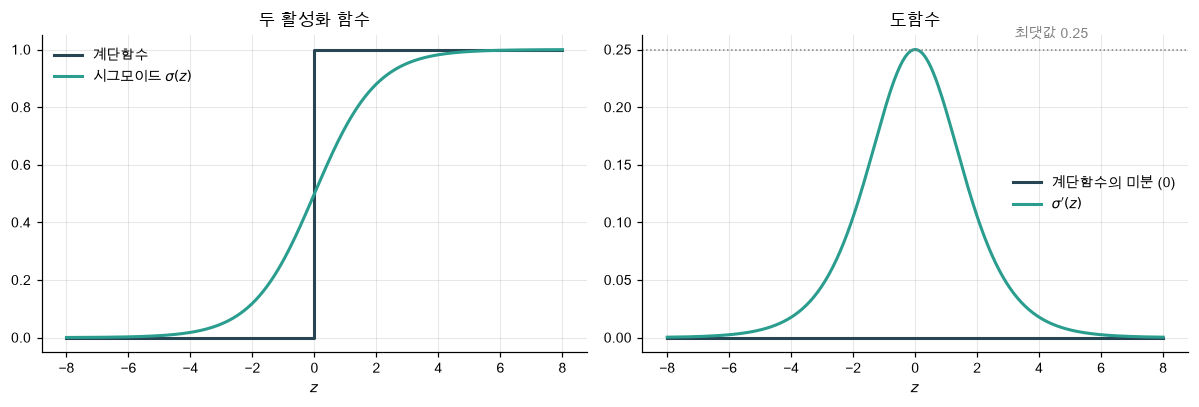

계단함수의 미분은 어디서나 0이다 — 경사하강이 쓸 정보가 없다.
시그모이드의 도함수는 z=0 에서 0.25로 최대이고, 양끝에서 0으로 죽는다(포화).
이 0.25 라는 상한이 나중에 기울기 소실 문제의 원인이 된다.


In [3]:
zs = np.linspace(-8, 8, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].step(zs, (zs > 0).astype(float), where="mid", lw=2, label="계단함수")
axes[0].plot(zs, sigmoid(zs), lw=2, label=r"시그모이드 $\sigma(z)$")
axes[0].set_title("두 활성화 함수"); axes[0].set_xlabel("$z$")

axes[1].plot(zs, np.zeros_like(zs), lw=2, label="계단함수의 미분 (0)")
axes[1].plot(zs, sigmoid(zs) * (1 - sigmoid(zs)), lw=2, label=r"$\sigma'(z)$")
axes[1].axhline(0.25, color="gray", ls=":", lw=1)
axes[1].annotate("최댓값 0.25", (3.2, 0.26), fontsize=9, color="gray")
axes[1].set_title("도함수"); axes[1].set_xlabel("$z$")

for ax in axes:
    ax.legend()
plt.show()

print("계단함수의 미분은 어디서나 0이다 — 경사하강이 쓸 정보가 없다.")
print("시그모이드의 도함수는 z=0 에서 0.25로 최대이고, 양끝에서 0으로 죽는다(포화).")
print("이 0.25 라는 상한이 나중에 기울기 소실 문제의 원인이 된다.")

### 도함수 유도

$\sigma(z) = (1 + e^{-z})^{-1}$ 에 연쇄법칙을 적용한다.

$$ \sigma'(z) = -(1+e^{-z})^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1+e^{-z})^2} $$

여기서 $e^{-z} = \dfrac{1}{\sigma} - 1 = \dfrac{1-\sigma}{\sigma}$ 임을 쓰면

$$ \sigma'(z) = \frac{1-\sigma}{\sigma} \cdot \sigma^2 = \boxed{\;\sigma(z)\,\bigl(1 - \sigma(z)\bigr)\;} $$

**도함수가 자기 자신으로 표현된다.** 그래서 forward에서 계산한 $\sigma(z)$ 를
캐시해 두면 backward에서 곱셈 두 번이면 끝난다. 앞으로 만들 활성화 함수들도
대부분 이런 성질을 갖는다.

In [4]:
# 성분별 함수이므로 야코비안이 대각이고, backward 는 성분곱이 된다.
sigmoid_backward = lambda dout, z: dout * sigmoid(z) * (1 - sigmoid(z))

err = check_function(sigmoid, sigmoid_backward,
                     np.array([-3.0, -1.0, 0.0, 0.5, 2.0, 4.0]), verbose=True)

[gradcheck] sigmoid
  ok   dx  rel_err = 1.195e-10


---

## 2. 문제 — 이미지 이진 분류

코세라는 고양이/비고양이 사진을 쓴다. 여기서는 다운로드 없이 재현할 수 있도록
**원 vs 십자** 합성 이미지를 만들었다 (`src/data/toy.py`).
도형의 중심 위치와 크기가 무작위로 흔들리고 잡음이 얹혀 있어서,
선형 분류기로 완벽히는 풀리지 않는다.

이미지를 쓰는 이유가 하나 더 있다. 학습이 끝난 뒤 **가중치 벡터를 이미지로 되돌려
보면**, 모델이 무엇을 보고 판단하는지 눈으로 확인할 수 있다.

이미지 (600, 16, 16),  라벨 (600,),  십자 비율 0.537


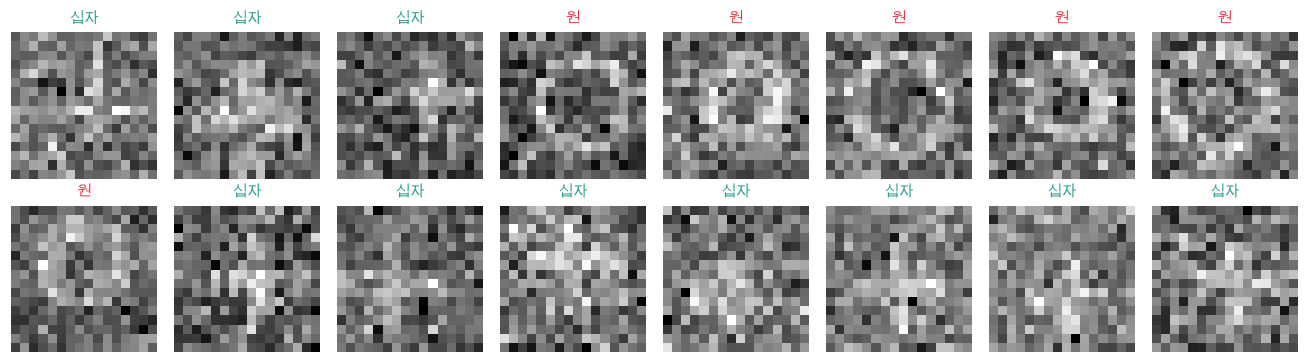

In [5]:
X_img, y = shapes(n_samples=600, size=16, noise=0.6, jitter=2.0, seed=0)
print(f"이미지 {X_img.shape},  라벨 {y.shape},  십자 비율 {y.mean():.3f}")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, img, label in zip(axes.ravel(), X_img, y):
    ax.imshow(img); ax.axis("off")
    ax.set_title("십자" if label else "원", fontsize=10,
                 color=COLOR_POS if label else COLOR_NEG)
plt.show()

### 이미지를 벡터로

$16 \times 16$ 이미지를 길이 $256$ 벡터로 편다. 로지스틱 회귀는 픽셀의
공간 배치를 모르고, 그냥 256개의 숫자로 본다.
(공간 구조를 살리는 것은 C4의 합성곱이 할 일이다.)

**모양 규약.** 이 프로젝트는 $X$ 를 `(m, n)` — 샘플이 행 — 으로 둔다.
코세라 강의는 `(n, m)` 으로 전치해서 쓰므로 수식을 대조할 때 주의한다.
행 우선이 numpy 의 기본 메모리 배치와 맞아서 이쪽을 택했다.

In [6]:
m_train = 400
X = X_img.reshape(len(X_img), -1)          # (600, 256)
X_train, y_train = X[:m_train], y[:m_train]
X_test,  y_test  = X[m_train:], y[m_train:]

m, n = X_train.shape
print(f"X_train {X_train.shape}   (m={m} 샘플, n={n} 특성)")
print(f"X_test  {X_test.shape}")

X_train (400, 256)   (m=400 샘플, n=256 특성)
X_test  (200, 256)


---

## 3. 모델 — 뉴런 하나

$$ z = w \cdot x + b, \qquad a = \sigma(z) $$

퍼셉트론과 **똑같은 $z$** 다. 바뀐 것은 그 뒤에 붙은 함수뿐이다.

$a$ 는 $(0,1)$ 값이므로 확률로 읽는다.

$$ a = P(y = 1 \mid x) $$

$w$ 는 각 픽셀의 중요도이고, 부호는 방향이다.
$w_j > 0$ 인 픽셀이 밝으면 "십자" 쪽으로, $w_j < 0$ 이면 "원" 쪽으로 민다.

---

## 4. 손실함수 — 왜 로그 손실인가

### 최대우도에서 유도한다

모델이 주장하는 것은 $P(y=1 \mid x) = a$ 이고, 따라서 $P(y=0\mid x) = 1-a$ 다.
$y \in \{0,1\}$ 이므로 이 둘을 한 줄로 쓸 수 있다.

$$ P(y \mid x) = a^{\,y}\,(1-a)^{\,1-y} $$

($y=1$ 이면 $a$, $y=0$ 이면 $1-a$ 가 된다.) 이 확률을 **최대화**하고 싶다.
곱을 합으로 바꾸기 위해 로그를 취하고, 최대화를 최소화로 바꾸기 위해 부호를 뒤집으면

$$ \boxed{\;\mathcal{L}(a, y) = -\bigl[\,y \log a + (1-y)\log(1-a)\,\bigr]\;} $$

$m$ 개 샘플 전체에 대해서는 평균을 쓴다. $J = \frac{1}{m}\sum_{i} \mathcal{L}(a^{(i)}, y^{(i)})$.

임의로 고른 식이 아니라 **최대우도 추정이 그대로 나온 것**이다.

### 제곱오차를 쓰면 안 되는 이유

$\mathcal{L} = \frac{1}{2}(a-y)^2$ 도 그럴듯해 보인다. 두 가지 문제가 있다.

**(1) 비볼록이 된다.** $\sigma$ 가 안에 끼어 있어서 $w$ 에 대해 볼록성이 깨진다.
지역 최솟값이 생길 수 있다.

**(2) 포화 구간에서 기울기가 죽는다.** 이쪽이 실질적으로 더 치명적이다.
두 손실의 $\partial \mathcal{L}/\partial z$ 를 비교해 보면 (유도는 다음 절에서)

$$ \text{로그 손실: } \frac{\partial \mathcal{L}}{\partial z} = a - y, \qquad
   \text{제곱 오차: } \frac{\partial \mathcal{L}}{\partial z} = (a-y)\,\underbrace{a(1-a)}_{\sigma'} $$

제곱오차에는 $\sigma'$ 이 곱해져 있다. $y=1$ 인데 $a = 0.001$ 을 냈다면
**완전히 틀린 상황**인데도 $\sigma' \approx 0.001$ 이라 기울기가 거의 0이 된다.
가장 크게 틀렸을 때 가장 적게 배우는 셈이다.

로그 손실은 $\log$ 의 미분이 만드는 $1/a$ 가 $\sigma'$ 의 $a$ 와 **약분되어**
이 문제를 없앤다. 두 함수가 서로를 위해 만들어진 것처럼 맞물린다.

아래에서 둘 다 수치로 확인한다.

로그 손실: 최소 곡률 +0.0010,  곡률이 음수인 구간 0.0%  →  볼록
제곱 오차: 최소 곡률 -0.1911,  곡률이 음수인 구간 47.6%  →  비볼록


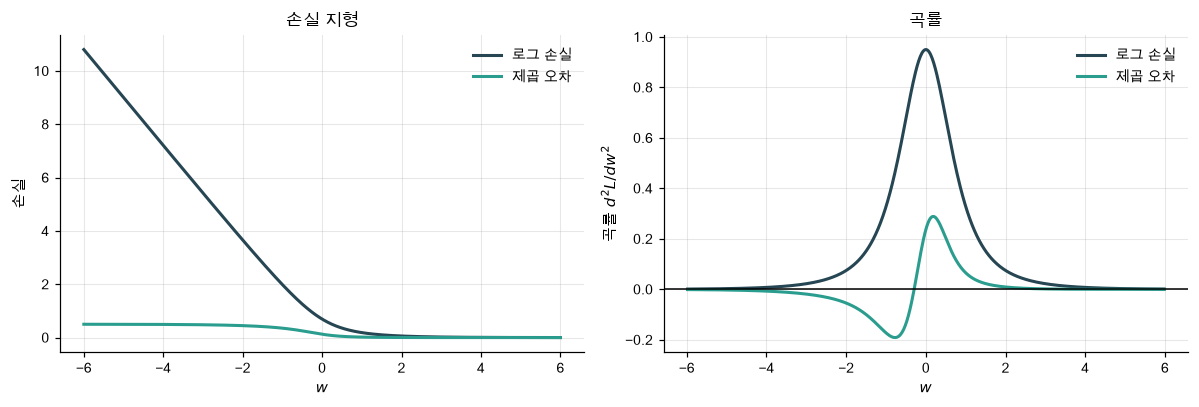

In [7]:
# (1) 볼록성 — 1차원 문제에서 w 를 훑으며 손실의 2차 차분(곡률)을 잰다
x1 = np.array([-2.0, -1.0, 1.0, 2.0, 3.0])
y1 = np.array([0.0, 0.0, 1.0, 1.0, 1.0])
ws = np.linspace(-6, 6, 601)

A = sigmoid(np.outer(ws, x1))                       # (601, 5)
L_log = -np.mean(y1 * np.log(A + 1e-300) + (1 - y1) * np.log(1 - A + 1e-300), axis=1)
L_sq = np.mean((A - y1) ** 2, axis=1) / 2

h = ws[1] - ws[0]
curv = lambda L: (L[2:] - 2 * L[1:-1] + L[:-2]) / h ** 2

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(ws, L_log, lw=2, label="로그 손실")
axes[0].plot(ws, L_sq, lw=2, label="제곱 오차")
axes[0].set_xlabel("$w$"); axes[0].set_ylabel("손실"); axes[0].set_title("손실 지형")

for name, L, in [("로그 손실", L_log), ("제곱 오차", L_sq)]:
    c = curv(L)
    axes[1].plot(ws[1:-1], c, lw=2, label=name)
    print(f"{name}: 최소 곡률 {c.min():+.4f},  곡률이 음수인 구간 "
          f"{(c < -1e-9).mean():.1%}  →  {'볼록' if c.min() > -1e-9 else '비볼록'}")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("$w$"); axes[1].set_ylabel("곡률 $d^2L/dw^2$"); axes[1].set_title("곡률")

for ax in axes:
    ax.legend()
plt.show()

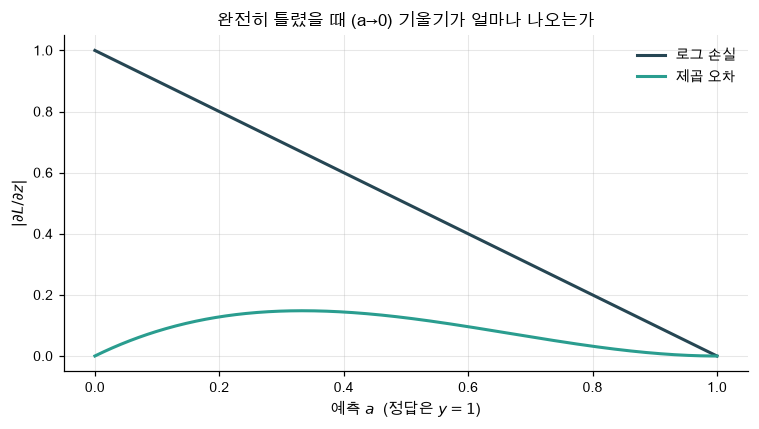

       a         로그손실           제곱오차         배율
------------------------------------------------
     0.5    -0.500000    -0.12500000         4배
     0.1    -0.900000    -0.08100000        11배
    0.01    -0.990000    -0.00980100       101배
   0.001    -0.999000    -0.00099800      1001배

a=0.001 이면 정답이 1인데 0.001 을 낸 것 — 최악의 오답이다.
그런데 제곱오차의 기울기는 로그 손실보다 1000배 약하다.


In [8]:
# (2) 포화 구간의 기울기 — y=1 인 샘플에서 a 가 0 에 가까울수록 격차가 벌어진다
a_grid = np.linspace(1e-4, 1 - 1e-4, 500)
g_log = a_grid - 1.0                       # dL/dz,  로그 손실
g_sq = (a_grid - 1.0) * a_grid * (1 - a_grid)   # dL/dz,  제곱 오차

fig, ax = plt.subplots()
ax.plot(a_grid, np.abs(g_log), lw=2, label="로그 손실")
ax.plot(a_grid, np.abs(g_sq), lw=2, label="제곱 오차")
ax.set_xlabel("예측 $a$  (정답은 $y=1$)"); ax.set_ylabel(r"$|\partial L/\partial z|$")
ax.set_title("완전히 틀렸을 때 (a→0) 기울기가 얼마나 나오는가")
ax.legend()
plt.show()

print(f"{'a':>8} {'로그손실':>12} {'제곱오차':>14} {'배율':>10}")
print("-" * 48)
for a in [0.5, 0.1, 0.01, 0.001]:
    gl, gs = a - 1.0, (a - 1.0) * a * (1 - a)
    print(f"{a:>8} {gl:>12.6f} {gs:>14.8f} {abs(gl / gs):>9.0f}배")
print()
print("a=0.001 이면 정답이 1인데 0.001 을 낸 것 — 최악의 오답이다.")
print("그런데 제곱오차의 기울기는 로그 손실보다 1000배 약하다.")

---

## 5. 계산 그래프와 역전파

코세라가 강조하는 도구다. 계산을 노드로 쪼개고, 뒤에서부터 국소 미분을 곱해 온다.

```
  w ──┐
      ├──→  z = w·x + b  ──→  a = σ(z)  ──→  L = -[y log a + (1-y) log(1-a)]
  x ──┤
  b ──┘
      ←─── dw, db  ←───  dz  ←───────────  da  ←──────────────  1
```

뒤에서부터 한 단계씩 간다.

**1단계 — $\mathrm{d}a = \partial L/\partial a$**

$$ \frac{\partial L}{\partial a} = -\frac{y}{a} + \frac{1-y}{1-a} $$

**2단계 — $\mathrm{d}z = \partial L/\partial z$.** 여기가 이 노트북의 핵심이다.

$$ \frac{\partial L}{\partial z} = \frac{\partial L}{\partial a}\cdot\frac{\partial a}{\partial z}
 = \left(-\frac{y}{a} + \frac{1-y}{1-a}\right)\cdot a(1-a) $$

전개하면

$$ = -\frac{y\,a(1-a)}{a} + \frac{(1-y)\,a(1-a)}{1-a} = -y(1-a) + (1-y)a = -y + ya + a - ya $$

$$ \boxed{\;\frac{\partial L}{\partial z} = a - y\;} $$

**"예측 빼기 정답"** 하나로 정리된다. $\sigma'$ 의 $a(1-a)$ 가 로그 미분의 분모와
정확히 약분된 결과다. 앞 절에서 말한 "두 함수가 맞물린다"가 이것이다.

수치적으로도 중요하다. $\mathrm{d}a$ 는 $a \to 0$ 일 때 $1/a$ 로 발산하지만,
$\mathrm{d}z$ 는 항상 $[-1, 1]$ 안에 있다. **그래서 두 단계를 절대 따로 구현하지 않는다.**

**3단계 — 파라미터**

$z = w\cdot x + b$ 이므로 $\partial z/\partial w_j = x_j$, $\partial z/\partial b = 1$.

$$ \mathrm{d}w = x \cdot \mathrm{d}z, \qquad \mathrm{d}b = \mathrm{d}z $$

C2W3의 softmax + 교차엔트로피에서 $\mathrm{d}z = p - y$ 라는 똑같은 구조가 다시 나온다.
이진의 다중 클래스 일반화다.

In [9]:
# 유도한 dz = a - y 를 수치미분으로 확인한다.
# z 를 입력으로 보고, L(z) 를 스칼라 손실로 두면 dL/dz 를 직접 잴 수 있다.
y_demo = np.array([1.0, 0.0, 1.0, 0.0, 1.0])

def loss_of_z(z):
    a = sigmoid(z)
    return -(y_demo * np.log(a) + (1 - y_demo) * np.log(1 - a))

def dz_analytic(dout, z):
    return dout * (sigmoid(z) - y_demo)      # 유도한 식

check_function(loss_of_z, dz_analytic,
               np.array([2.0, -1.5, 0.3, 1.2, -0.7]), verbose=True, name="dz = a - y")

# da 를 거쳐 두 단계로 계산해도 같은지 확인 (수학적으로 동일)
z_demo = np.array([2.0, -1.5, 0.3, 1.2, -0.7])
a_demo = sigmoid(z_demo)
da = -y_demo / a_demo + (1 - y_demo) / (1 - a_demo)
two_step = da * a_demo * (1 - a_demo)
print(f"\n두 단계로 계산: {two_step}")
print(f"한 번에 (a - y): {a_demo - y_demo}")
print(f"최대 차이: {np.abs(two_step - (a_demo - y_demo)).max():.2e}")

[gradcheck] dz = a - y
  ok   dx  rel_err = 1.511e-10

두 단계로 계산: [-0.1192  0.1824 -0.4256  0.7685 -0.6682]
한 번에 (a - y): [-0.1192  0.1824 -0.4256  0.7685 -0.6682]
최대 차이: 0.00e+00


---

## 6. $m$ 개 샘플 — 먼저 반복문으로

$$ J = \frac{1}{m}\sum_{i=1}^{m} \mathcal{L}\bigl(a^{(i)}, y^{(i)}\bigr), \qquad
   \frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m} x^{(i)}\,\mathrm{d}z^{(i)} $$

수식을 그대로 옮기면 이중 반복문이 된다. 샘플 하나씩, 그 안에서 특성 하나씩.
느리지만 **수식과 코드가 1:1로 대응**해서 처음에는 이쪽이 읽기 쉽다.

In [10]:
def propagate_loop(w, b, X, y):
    # 수식을 그대로 옮긴 이중 반복문. 느리지만 대응 관계가 명확하다.
    m, n = X.shape
    cost = 0.0
    dw = np.zeros(n)
    db = 0.0
    for i in range(m):
        z = 0.0
        for j in range(n):                      # w·x 를 손으로
            z += w[j] * X[i, j]
        z += b
        a = float(sigmoid(np.array(z)))
        a = min(max(a, 1e-12), 1 - 1e-12)   # log 발산 방지 (1절)
        cost += -(y[i] * np.log(a) + (1 - y[i]) * np.log(1 - a))
        dz = a - y[i]                           # 5절에서 유도한 식
        for j in range(n):
            dw[j] += X[i, j] * dz
        db += dz
    return cost / m, dw / m, db / m

w0 = np.zeros(n)
cost_loop, dw_loop, db_loop = propagate_loop(w0, 0.0, X_train, y_train)
print(f"손실 {cost_loop:.6f}   (log 2 = {np.log(2):.6f} — w=0 이면 모든 예측이 0.5)")
print(f"dw 처음 5개 {dw_loop[:5]}")
print(f"db {db_loop:.6f}")

손실 0.693147   (log 2 = 0.693147 — w=0 이면 모든 예측이 0.5)
dw 처음 5개 [-0.0176  0.0213  0.0066 -0.0047  0.0054]
db -0.052500


---

## 7. 벡터화

반복문을 행렬 연산으로 바꾼다. $X$ 가 `(m, n)` 이므로

$$ z = Xw + b \;\;\text{(m,)}, \qquad a = \sigma(z), \qquad
   \mathrm{d}z = a - y, \qquad \mathrm{d}w = \frac{1}{m}X^\top \mathrm{d}z, \qquad
   \mathrm{d}b = \frac{1}{m}\sum_i \mathrm{d}z_i $$

**브로드캐스팅.** `Xw` 는 `(m,)` 이고 `b` 는 스칼라인데 `Xw + b` 가 그냥 된다.
numpy 가 `b` 를 모든 원소에 자동으로 복사해 주기 때문이다.
그리고 그 대가로 **backward 에서는 합이 된다** — `db = dz.sum() / m` 에서
$\sum$ 이 나타나는 이유가 이것이다. forward 에서 복사한 것은
backward 에서 더해서 되돌린다. 이 규칙은 앞으로 계속 쓰인다.

속도 차이는 numpy 의 행렬 연산이 최적화된 C/BLAS 루틴으로 내려가기 때문이다.
파이썬 반복문은 원소마다 인터프리터를 거친다.

In [11]:
EPS = 1e-12   # a 가 정확히 0 또는 1 이 되면 log 가 발산한다 (1절 참고)

def binary_cross_entropy(a, y):
    a = np.clip(a, EPS, 1 - EPS)
    return -np.mean(y * np.log(a) + (1 - y) * np.log(1 - a))

def propagate(w, b, X, y):
    # 6절의 반복문과 완전히 같은 계산. 반복문이 전부 행렬 연산으로 바뀌었다.
    m = X.shape[0]
    a = sigmoid(X @ w + b)                    # (m,)
    cost = binary_cross_entropy(a, y)
    dz = a - y                                # (m,)  — 클리핑은 손실에만, 기울기는 원래 a 로
    dw = X.T @ dz / m                         # (n,)
    db = dz.sum() / m                         # 스칼라
    return cost, dw, db

cost_vec, dw_vec, db_vec = propagate(w0, 0.0, X_train, y_train)

print("두 구현이 같은 값을 내는가")
print(f"  손실 차이 {abs(cost_loop - cost_vec):.3e}")
print(f"  dw  차이 {np.abs(dw_loop - dw_vec).max():.3e}")
print(f"  db  차이 {abs(db_loop - db_vec):.3e}")

t0 = time.perf_counter(); propagate_loop(w0, 0.0, X_train, y_train)
t_loop = time.perf_counter() - t0
t0 = time.perf_counter()
for _ in range(100):
    propagate(w0, 0.0, X_train, y_train)
t_vec = (time.perf_counter() - t0) / 100

print(f"\n반복문   {t_loop * 1000:8.2f} ms")
print(f"벡터화   {t_vec * 1000:8.3f} ms")
print(f"→ 약 {t_loop / t_vec:.0f}배 빠르다  (m={m}, n={n})")
print("\n앞으로 모든 것을 벡터화로 쓴다. 규모가 커질수록 격차가 벌어진다.")

두 구현이 같은 값을 내는가
  손실 차이 1.554e-15
  dw  차이 0.000e+00
  db  차이 0.000e+00

반복문      32.52 ms
벡터화      0.032 ms
→ 약 1026배 빠르다  (m=400, n=256)

앞으로 모든 것을 벡터화로 쓴다. 규모가 커질수록 격차가 벌어진다.


---

## 8. 검증 — 전체 기울기를 수치미분과 대조

5절에서 $\mathrm{d}z$ 만 확인했다. 이제 $\mathrm{d}w$ 와 $\mathrm{d}b$ 까지
손실 $J$ 를 직접 흔들어 확인한다. 학습을 돌리기 **전에** 하는 것이 요령이다.
여기가 틀린 채로 학습을 돌리면 원인을 하이퍼파라미터에서 찾게 된다.

In [12]:
w_test = np.random.default_rng(0).standard_normal(n) * 0.1
b_test = 0.3

# w 에 대해: J(w) 를 w 의 함수로 보고 check_function 에 넘긴다
check_function(lambda w: np.array(propagate(w, b_test, X_train, y_train)[0]),
               lambda dout, w: dout * propagate(w, b_test, X_train, y_train)[1],
               w_test, verbose=True, name="dw")

# b 에 대해: 스칼라라서 (1,) 배열로 감싼다
check_function(lambda bb: np.array(propagate(w_test, bb[0], X_train, y_train)[0]),
               lambda dout, bb: dout * np.array([propagate(w_test, bb[0], X_train, y_train)[2]]),
               np.array([b_test]), verbose=True, name="db")

[gradcheck] dw
  ok   dx  rel_err = 9.996e-10
[gradcheck] db
  ok   dx  rel_err = 6.070e-10


6.069697794009111e-10

---

## 9. 학습

경사하강. 기울기의 반대 방향으로 조금씩 간다.

$$ w \leftarrow w - \alpha\,\mathrm{d}w, \qquad b \leftarrow b - \alpha\,\mathrm{d}b $$

00번의 퍼셉트론 학습 규칙과 겉모습은 비슷하지만 성격이 다르다.
저쪽은 "틀린 샘플을 그쪽으로 민다"는 별도 규칙이었고,
이쪽은 **정의된 손실함수의 기울기**를 따라간다. 그래서 손실이 단조롭게 내려가고,
로그 손실이 볼록하므로 전역 최솟값으로 수렴한다.

In [13]:
def fit(X, y, X_val, y_val, lr=0.1, n_iter=2000, log_every=400):
    w, b = np.zeros(X.shape[1]), 0.0
    history = {"cost": [], "train_acc": [], "val_acc": []}
    for it in range(n_iter + 1):
        cost, dw, db = propagate(w, b, X, y)
        history["cost"].append(cost)
        history["train_acc"].append(np.mean((sigmoid(X @ w + b) > 0.5) == y))
        history["val_acc"].append(np.mean((sigmoid(X_val @ w + b) > 0.5) == y_val))
        if log_every and it % log_every == 0:
            print(f"  {it:5d}  손실 {cost:.4f}   학습 {history['train_acc'][-1]:.3f}"
                  f"   검증 {history['val_acc'][-1]:.3f}")
        w -= lr * dw
        b -= lr * db
    return w, b, history

print("반복    손실     학습정확도  검증정확도")
w, b, hist = fit(X_train, y_train, X_test, y_test, lr=0.1, n_iter=2000)

반복    손실     학습정확도  검증정확도
      0  손실 0.6931   학습 0.448   검증 0.495
    400  손실 0.0257   학습 1.000   검증 0.930
    800  손실 0.0139   학습 1.000   검증 0.930
   1200  손실 0.0096   학습 1.000   검증 0.925


   1600  손실 0.0073   학습 1.000   검증 0.925
   2000  손실 0.0059   학습 1.000   검증 0.925


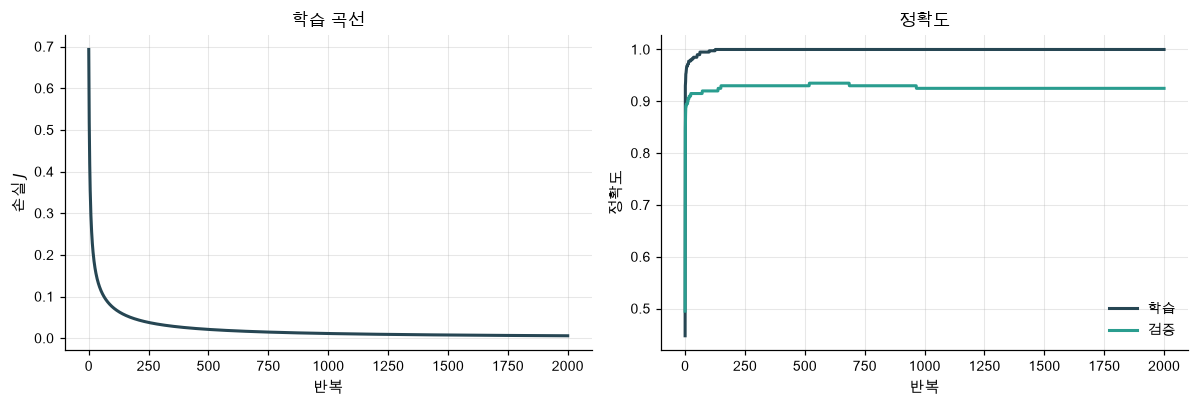

최종 학습 정확도 1.000
최종 검증 정확도 0.925
차이 0.075  ← 과적합

학습 데이터는 완벽히 맞히는데 검증에서는 틀린다.
파라미터가 257개인데 학습 샘플이 400개뿐이라 외워 버린 것이다.
이 문제를 다루는 것이 C2W1(정규화)이다.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(hist["cost"], lw=2)
axes[0].set_xlabel("반복"); axes[0].set_ylabel("손실 $J$"); axes[0].set_title("학습 곡선")
axes[1].plot(hist["train_acc"], lw=2, label="학습")
axes[1].plot(hist["val_acc"], lw=2, label="검증")
axes[1].set_xlabel("반복"); axes[1].set_ylabel("정확도"); axes[1].set_title("정확도")
axes[1].legend()
plt.show()

print(f"최종 학습 정확도 {hist['train_acc'][-1]:.3f}")
print(f"최종 검증 정확도 {hist['val_acc'][-1]:.3f}")
print(f"차이 {hist['train_acc'][-1] - hist['val_acc'][-1]:.3f}  ← 과적합")
print()
print("학습 데이터는 완벽히 맞히는데 검증에서는 틀린다.")
print("파라미터가 257개인데 학습 샘플이 400개뿐이라 외워 버린 것이다.")
print("이 문제를 다루는 것이 C2W1(정규화)이다.")

---

## 10. 모델은 무엇을 보고 판단하는가

$w$ 는 픽셀마다 하나씩, 총 256개다. 이미지와 같은 $16\times16$ 으로 되돌리면
**모델이 학습한 것을 그림으로 볼 수 있다.**

$z = w\cdot x + b$ 이고 $a = \sigma(z)$ 이므로

- $w_j > 0$ 인 픽셀이 밝으면 → $z$ 증가 → **십자** 쪽
- $w_j < 0$ 인 픽셀이 밝으면 → $z$ 감소 → **원** 쪽

즉 가중치 이미지는 두 클래스의 **차이 지도**다.
십자는 중앙과 축을 채우고, 원은 중앙이 비고 고리가 있다.
그 차이가 그대로 나타나는지 확인해 보자.

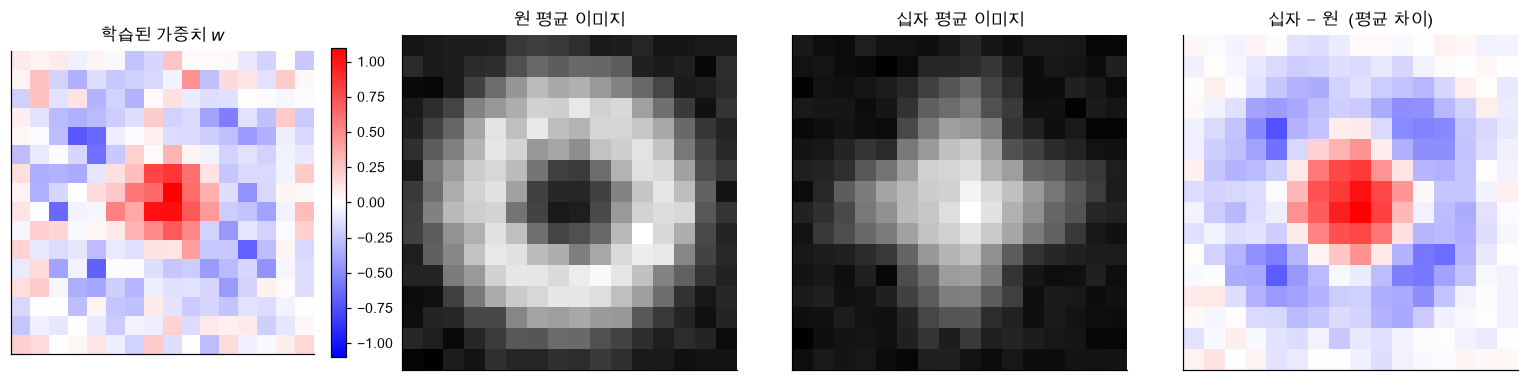

가중치와 평균 차이 이미지의 상관계수: 0.852

가중치가 중앙에서 붉고(십자 쪽) 그 바깥 고리에서 푸르다(원 쪽).
학습이 두 클래스의 차이를 그대로 찾아냈다 — 아무도 알려주지 않았는데도.


In [15]:
W_img = w.reshape(16, 16)
lim = np.abs(W_img).max()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))

im = axes[0].imshow(W_img, cmap="bwr", vmin=-lim, vmax=lim)
axes[0].set_title("학습된 가중치 $w$")
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow(X_img[y == 0].mean(axis=0))
axes[1].set_title("원 평균 이미지")
axes[2].imshow(X_img[y == 1].mean(axis=0))
axes[2].set_title("십자 평균 이미지")

diff = X_img[y == 1].mean(axis=0) - X_img[y == 0].mean(axis=0)
d = np.abs(diff).max()
axes[3].imshow(diff, cmap="bwr", vmin=-d, vmax=d)
axes[3].set_title("십자 − 원  (평균 차이)")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

corr = np.corrcoef(W_img.ravel(), diff.ravel())[0, 1]
print(f"가중치와 평균 차이 이미지의 상관계수: {corr:.3f}")
print()
print("가중치가 중앙에서 붉고(십자 쪽) 그 바깥 고리에서 푸르다(원 쪽).")
print("학습이 두 클래스의 차이를 그대로 찾아냈다 — 아무도 알려주지 않았는데도.")

---

## 11. 학습률

$\alpha$ 가 유일하게 손으로 정해야 하는 값이다 (**하이퍼파라미터**).
$w$ 와 $b$ 는 학습으로 정해지지만 $\alpha$ 는 그렇지 않다.

먼저 이 이미지 문제에서 학습률을 바꿔 본다. 결과가 조금 뜻밖일 것이다.

     학습률         최종 손실      검증 정확도      max|w|
------------------------------------------------
   0.001      0.364848       0.895    1.04e-01
    0.01      0.104542       0.915    3.56e-01


     0.1      0.018049       0.935    8.07e-01
     1.0      0.002041       0.925    1.37e+00


    10.0      0.000085       0.930    2.74e+00


   100.0      0.000000       0.935    2.53e+01


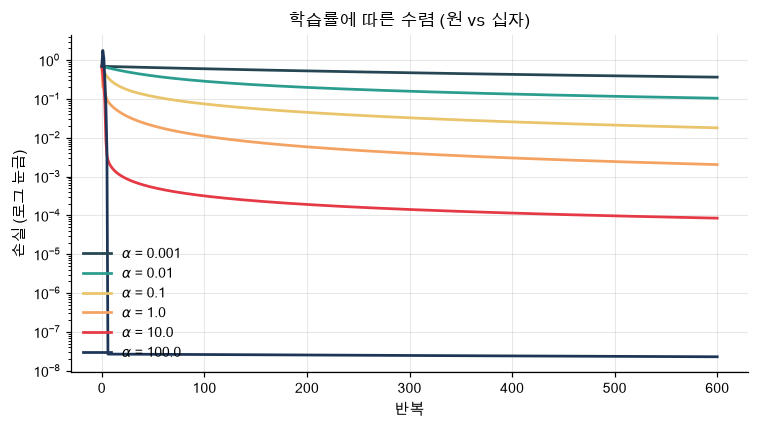


학습률을 아무리 키워도 발산하지 않고, 손실이 계속 0으로 내려간다.
대신 max|w| 가 학습률에 비례해 커진다. 왜 그럴까?


In [16]:
fig, ax = plt.subplots()
print(f"{'학습률':>8}  {'최종 손실':>12}  {'검증 정확도':>10}  {'max|w|':>10}")
print("-" * 48)
for lr in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    w_lr, _, h = fit(X_train, y_train, X_test, y_test, lr=lr, n_iter=600, log_every=0)
    ax.plot(h["cost"], lw=1.8, label=fr"$\alpha$ = {lr}")
    print(f"{lr:>8}  {h['cost'][-1]:>12.6f}  {h['val_acc'][-1]:>10.3f}  "
          f"{np.abs(w_lr).max():>10.2e}")

ax.set_yscale("log")
ax.set_xlabel("반복"); ax.set_ylabel("손실 (로그 눈금)")
ax.set_title("학습률에 따른 수렴 (원 vs 십자)"); ax.legend()
plt.show()

print()
print("학습률을 아무리 키워도 발산하지 않고, 손실이 계속 0으로 내려간다.")
print("대신 max|w| 가 학습률에 비례해 커진다. 왜 그럴까?")

### 왜 발산하지 않았나 — 이 데이터는 분리 가능하다

학습 정확도가 100%였다는 것은 **학습 데이터를 완벽히 가르는 직선이 존재한다**는 뜻이다.
그런 경우 로지스틱 회귀의 손실에는 **유한한 최솟값이 없다.**

분리하는 $w$ 를 찾았다면, $2w$ 는 모든 $z$ 를 두 배로 키우므로 예측이 더 확신에 차고
손실이 더 작아진다. $10w$ 는 더 작다. 즉

$$ \|w\| \to \infty \quad \Longrightarrow \quad J \to 0 $$

최솟값이 무한대에 있으니, 경사하강은 아무리 큰 걸음으로 가도 **지나칠 지점이 없다.**
학습률을 키우면 그저 더 빨리 커질 뿐이다. 위 표에서 `max|w|` 가
학습률에 비례해 커지는 것이 그 증거다.

이것은 좋은 일이 아니다. 가중치가 커질수록 모델은 학습 데이터에 과하게 확신하게 되고,
9절에서 본 과적합이 심해진다. **가중치가 커지는 것 자체에 벌점을 주는 것**이
L2 정규화이고, C2W1의 주제다.

### 겹치는 데이터에서는 진짜로 발산한다

최솟값이 유한한 곳에 있으면 이야기가 다르다. 두 덩어리가 많이 겹치는 2차원 데이터로
확인한다. 이제는 지나칠 지점이 있으므로, 걸음이 너무 크면 **최솟값을 뛰어넘어
반대편으로 더 멀리 가고**, 그것이 반복되며 손실이 커진다.

     학습률       시작 손실       최종 손실       최대 손실
----------------------------------------------
     0.1      0.6931      0.4432      0.6931


     1.0      0.6931      0.4432      0.6931
     5.0      0.6931      0.7068      1.3292   <- 발산
    20.0      0.6931      2.3749      5.7861   <- 발산
    50.0      0.6931      5.2706     15.6485   <- 발산


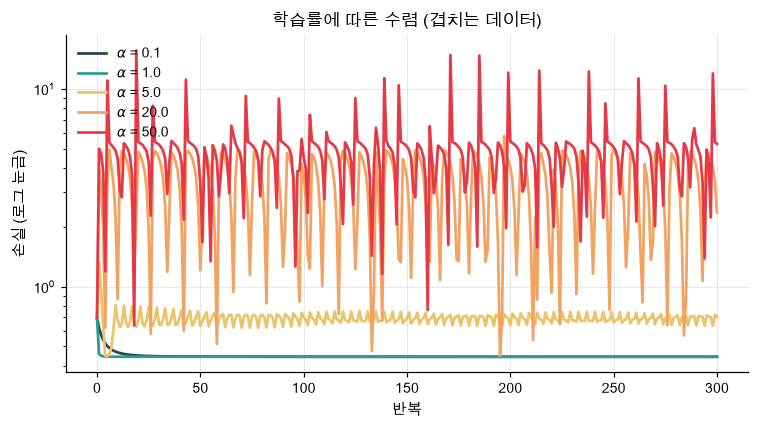


α = 5 부터 손실이 출렁이고, 20 이상에서는 시작보다 나빠진 채 끝난다.
최솟값이 유한한 곳에 있을 때 걸음이 크면 그것을 뛰어넘는다.
적절한 학습률은 문제마다 다르다 — 그래서 하이퍼파라미터다.


In [17]:
X_ov, y_ov = blobs(n_samples=300, noise=2.2, seed=3)   # 많이 겹치도록 잡음을 키움

fig, ax = plt.subplots()
print(f"{'학습률':>8}  {'시작 손실':>10}  {'최종 손실':>10}  {'최대 손실':>10}")
print("-" * 46)
for lr in [0.1, 1.0, 5.0, 20.0, 50.0]:
    _, _, h = fit(X_ov, y_ov, X_ov, y_ov, lr=lr, n_iter=300, log_every=0)
    ax.plot(h["cost"], lw=1.8, label=fr"$\alpha$ = {lr}")
    flag = "   <- 발산" if h["cost"][-1] > h["cost"][0] else ""
    print(f"{lr:>8}  {h['cost'][0]:>10.4f}  {h['cost'][-1]:>10.4f}  "
          f"{max(h['cost']):>10.4f}{flag}")

ax.set_yscale("log")
ax.set_xlabel("반복"); ax.set_ylabel("손실 (로그 눈금)")
ax.set_title("학습률에 따른 수렴 (겹치는 데이터)"); ax.legend()
plt.show()

print()
print("α = 5 부터 손실이 출렁이고, 20 이상에서는 시작보다 나빠진 채 끝난다.")
print("최솟값이 유한한 곳에 있을 때 걸음이 크면 그것을 뛰어넘는다.")
print("적절한 학습률은 문제마다 다르다 — 그래서 하이퍼파라미터다.")

---

## 12. 2차원에서 — 결정경계는 여전히 직선이다

256차원에서는 결정경계를 그릴 수 없으니 2차원 문제로 확인한다.

중요한 점: 시그모이드를 붙였어도 **결정경계는 여전히 직선**이다.
$a > 0.5 \iff z > 0 \iff w\cdot x + b > 0$ 이므로, 00번의 퍼셉트론과 똑같은 조건이다.

바뀐 것은 경계의 위치가 아니라 **경계 근처에서 확신도가 부드럽게 변한다**는 점,
그리고 그 덕분에 **학습이 가능해졌다**는 점이다.

그러므로 XOR은 여전히 못 푼다. 로지스틱 회귀는 뉴런 하나이고,
00번의 증명이 그대로 적용된다. 다음 노트북에서 은닉층을 붙이는 이유다.

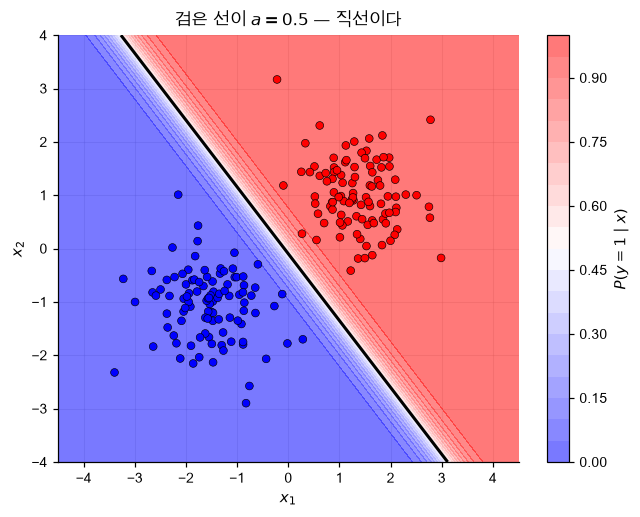

정확도 1.000
색이 부드럽게 변하는 것이 퍼셉트론과의 차이다 — 확신도를 표현한다.
하지만 경계 자체는 직선이므로 표현력은 퍼셉트론과 같다.


In [18]:
Xb, yb = blobs(n_samples=200, noise=0.7, seed=1)
wb, bb, _ = fit(Xb, yb, Xb, yb, lr=0.5, n_iter=1500, log_every=0)

xx, yy = np.meshgrid(np.linspace(-4.5, 4.5, 300), np.linspace(-4, 4, 300))
probs = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ wb + bb).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 4.8))
cf = ax.contourf(xx, yy, probs, levels=20, cmap="bwr", alpha=0.55)
ax.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=2)
ax.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="bwr", s=26, edgecolors="k", linewidths=0.4)
plt.colorbar(cf, ax=ax, label="$P(y=1 \\mid x)$")
ax.set_title("검은 선이 $a = 0.5$ — 직선이다")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.show()

print(f"정확도 {np.mean((sigmoid(Xb @ wb + bb) > 0.5) == yb):.3f}")
print("색이 부드럽게 변하는 것이 퍼셉트론과의 차이다 — 확신도를 표현한다.")
print("하지만 경계 자체는 직선이므로 표현력은 퍼셉트론과 같다.")

---

## 13. `src/`로 정착시키기 ✅

검증을 통과했고 앞으로 계속 쓸 것만 옮겼다.

| 옮긴 것 | 위치 | 이유 |
|---|---|---|
| `sigmoid`, `sigmoid_grad` | `src/functional.py` | 02번의 활성화 함수, 12번의 LSTM 게이트에서 다시 쓴다 |
| `binary_cross_entropy` | `src/losses.py` | 02, 03번에서 그대로 쓴다 |
| `binary_cross_entropy_grad` (`a - y`) | `src/losses.py` | 5절의 유도 결과 |
| 회귀 테스트 12개 | `tests/test_functional.py` | 이후 리팩터링에서 유도가 깨지면 잡아낸다 |

```python
from src import sigmoid, binary_cross_entropy, binary_cross_entropy_grad
```

`propagate` 와 `fit` 은 **옮기지 않았다.** 03번에서 `Layer` 추상화를 만들면
훨씬 일반적인 형태로 다시 쓰게 되기 때문이다. 지금 옮기면 곧 버릴 코드가 된다.

옮기는 기준은 "**모양이 확정되었는가**"다. 아직 흔들릴 것 같으면 노트북에 둔다.

### 테스트가 지키는 것

단순히 "돌아간다"가 아니라 **이 노트북에서 밝힌 사실들**을 고정해 둔다.

- `σ'` 의 최댓값이 0.25 인가 (기울기 소실의 원인)
- 극단적 입력에서 넘침 경고가 나지 않는가
- `a` 가 정확히 0/1 이어도 손실이 `nan` 이 되지 않는가 (클리핑)
- `dz = a - y` 가 수치미분과 일치하는가
- 그 기울기가 항상 `[-1, 1]` 안에 있는가

```bash
.venv/bin/python -m pytest tests/test_functional.py -v
```

---

## 정리

- **시그모이드**는 계단함수의 두 문제를 동시에 푼다 — 미분이 살아 있고, 확률을 표현한다
- **로그 손실**은 임의로 고른 것이 아니라 최대우도에서 나온다.
  제곱오차는 비볼록이고, 포화 구간에서 기울기가 1000배 약해진다
- $\sigma'$ 의 $a(1-a)$ 와 로그 미분의 $1/a$ 가 약분되어 $\mathrm{d}z = a - y$ 가 된다.
  **그래서 두 단계를 따로 구현하지 않는다**
- 브로드캐스팅한 축은 backward 에서 합이 된다 ($\mathrm{d}b = \sum \mathrm{d}z$)
- 벡터화는 같은 계산을 수백 배 빠르게 한다
- **하지만 결정경계는 여전히 직선이다.** 표현력은 퍼셉트론과 같다

마지막 항목이 다음 노트북으로 이어진다. 학습은 가능해졌지만
XOR은 여전히 못 푼다. 00번에서 배운 대로 **층을 쌓아야** 한다.

**다음:** `02_shallow_nn.ipynb` (C1W3) — 은닉층 하나를 붙이고,
**왜 비선형 활성화가 없으면 층을 쌓아도 소용없는지**를 확인한다.